In [ ]:
import geopandas as gpd

import matplotlib.pyplot as plt


In [7]:
path_commune = "./BDTOPO/ADMINISTRATIF/Commune.shp"
path_batiment = "./BDTOPO/BATI/Batiment.shp"
path_sport = "./BDTOPO/BATI/Terrain_de_sport.shp"
path_hydro = "./BDTOPO/HYDROGRAPHIE/Cours_d_eau.shp"
path_transport = "./BDTOPO/TRANSPORT/Equipement_de_transport.shp"
path_vegetation = "./BDTOPO/OCCUPATION_DU_SOL/Zone_de_vegetation.shp"

gdf_commune = gpd.read_file(path_commune)
gdf_batiment = gpd.read_file(path_batiment)
gdf_sport = gpd.read_file(path_sport)
gdf_hydro = gpd.read_file(path_hydro)
gdf_transport = gpd.read_file(path_transport)
gdf_vegetation = gpd.read_file(path_vegetation)

/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Error parsing datetimes, original strings are returned: Out of bounds nanosecond timestamp: 1650-01-01, at position 108. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


In [8]:
# a. Conserver uniquement Paris dans Commune
gdf_paris = gdf_commune[gdf_commune["NOM"] == "Paris"].copy()

# b. Conserver uniquement les stations de métro
gdf_metro = gdf_transport[gdf_transport["NATURE"] == "Station de métro"].copy()

# c. Conserver uniquement les habitations 'Résidentiel'
gdf_residentiel = gdf_batiment[gdf_batiment["USAGE1"] == "Résidentiel"].copy()


In [13]:
gdf_paris = gdf_paris.to_crs(epsg=2154)


def filter_by_paris(gdf: gpd.GeoDataFrame, mask: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Filtre une GeoDataFrame pour ne conserver que les éléments situés à l'intérieur de Paris."""
    gdf = gdf.to_crs(mask.crs)
    return gpd.clip(gdf, mask)

gdf_res_paris = filter_by_paris(gdf_residentiel, gdf_paris)
gdf_metro_paris = filter_by_paris(gdf_metro, gdf_paris)
gdf_sport_paris = filter_by_paris(gdf_sport, gdf_paris)
gdf_veg_paris = filter_by_paris(gdf_vegetation, gdf_paris)
gdf_hydro_paris = filter_by_paris(gdf_hydro, gdf_paris)


In [14]:
buffer_metro = gdf_metro_paris.buffer(250).union_all()
buffer_veg = gdf_veg_paris.buffer(100).union_all()
buffer_hydro = gdf_hydro_paris.buffer(100).union_all()
buffer_sport = gdf_sport_paris.buffer(750).union_all()

res_final = gdf_res_paris[
    gdf_res_paris.geometry.intersects(buffer_metro)
    & gdf_res_paris.geometry.intersects(buffer_veg)
    & gdf_res_paris.geometry.intersects(buffer_hydro)
    & gdf_res_paris.geometry.intersects(buffer_sport)
]


In [15]:
# Résultat
print(f"Nombre d'habitations respectant les critères : {len(res_final)}")

Nombre d'habitations respectant les critères : 1125


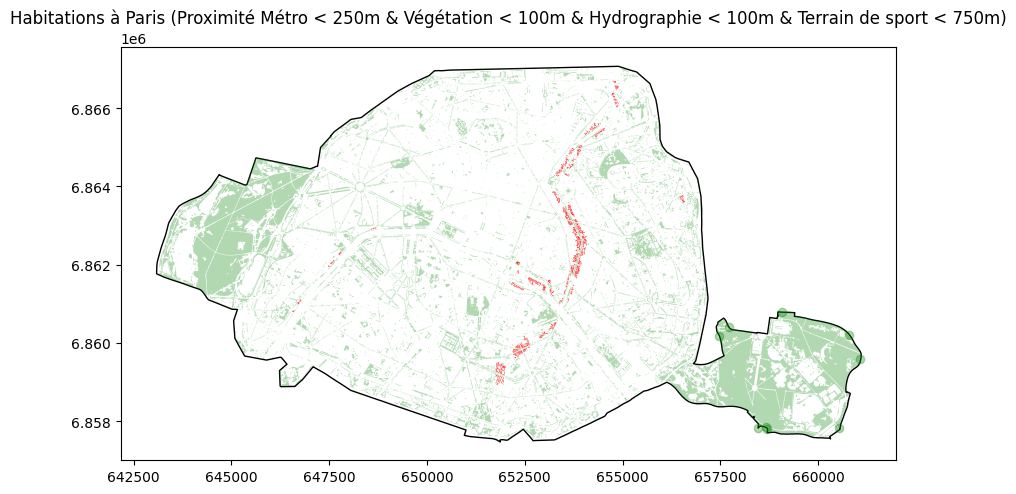

In [17]:
# Visualisation rapide
ax = gdf_paris.plot(color="white", edgecolor="black", figsize=(10, 10))
gdf_veg_paris.plot(ax=ax, color="green", alpha=0.3)
res_final.plot(ax=ax, color="red", markersize=1)
plt.title("Habitations à Paris (Proximité Métro < 250m & Végétation < 100m & Hydrographie < 100m & Terrain de sport < 750m)")
plt.show()
